<a href="https://colab.research.google.com/github/Sharvesh8326/24ADI003_24BAD110_ML/blob/main/24BAD110_EXP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sharvesh S
Roll No: 24BAD110
Scenario 1: Multilinear Regression

MSE: 179.6023423362354
RMSE: 13.401579844788278
R2 Score: 0.16217185763155206

Regression Coefficients:
                                                Coefficient
gender_male                                      -2.044602
race/ethnicity_group B                           -0.054856
race/ethnicity_group C                            0.427839
race/ethnicity_group D                            1.662529
race/ethnicity_group E                            2.068116
parental level of education_bachelor's degree     1.129806
parental level of education_high school          -1.848668
parental level of education_master's degree       0.454377
parental level of education_some college         -0.357219
parental level of education_some high school     -1.254711
lunch_standard                                    4.405985
test preparation course_none                     -3.776664


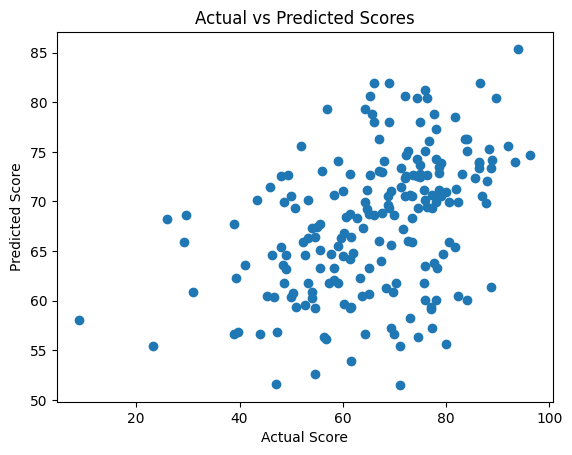

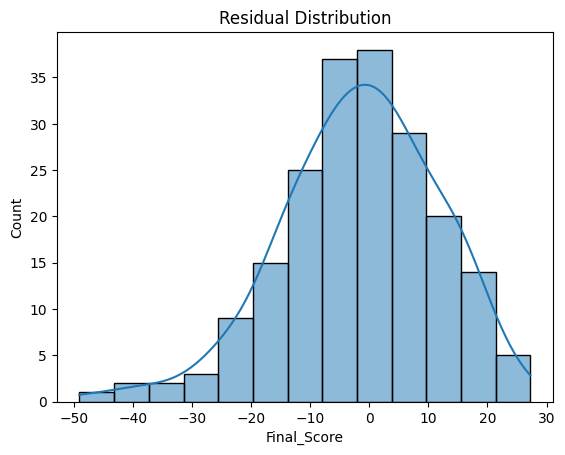

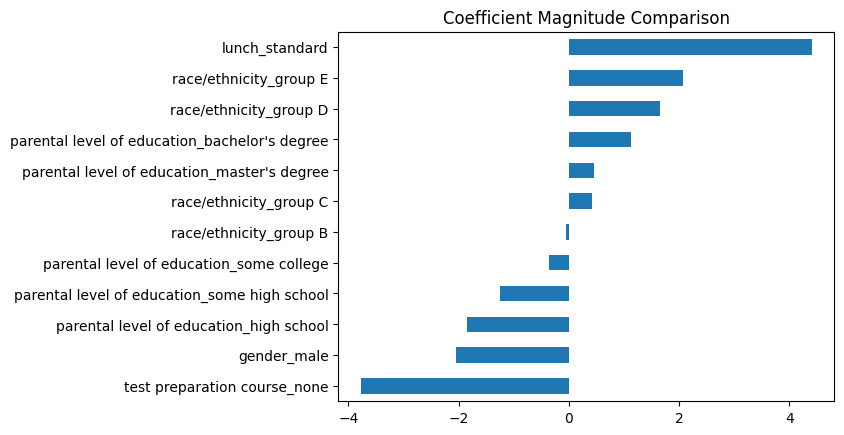

Ridge R2: 0.16211577444109382
Lasso R2: 0.15565398919126605


In [1]:
# Scenario 1: Multilinear Regression

print("Name: Sharvesh S")
print("Roll No: 24BAD110")
print("Scenario 1: Multilinear Regression\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# Create Target Variable (Average Score)
df['Final_Score'] = (df['math score'] +
                     df['reading score'] +
                     df['writing score']) / 3

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Select features (after encoding)
features = df.drop(columns=['math score',
                            'reading score',
                            'writing score',
                            'Final_Score']).columns

X = df[features]
y = df['Final_Score']

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Coefficient Analysis
coeff_df = pd.DataFrame(model.coef_, index=X.columns,
                        columns=['Coefficient'])
print("\nRegression Coefficients:\n", coeff_df)

# Visualization - Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()

# Residual Distribution
residuals = y_test - y_pred
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Coefficient Magnitude Plot
plt.figure()
coeff_df['Coefficient'].sort_values().plot(kind='barh')
plt.title("Coefficient Magnitude Comparison")
plt.show()

# Optimization - Ridge & Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge R2:", r2_score(y_test, ridge.predict(X_test)))

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
print("Lasso R2:", r2_score(y_test, lasso.predict(X_test)))

Name: Sharvesh S
Roll No: 24BAD110
Scenario 2: Polynomial Regression


Polynomial Degree: 2
MSE: 18.41696779601779
RMSE: 4.291499481069267
R2: 0.6391701147013311


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


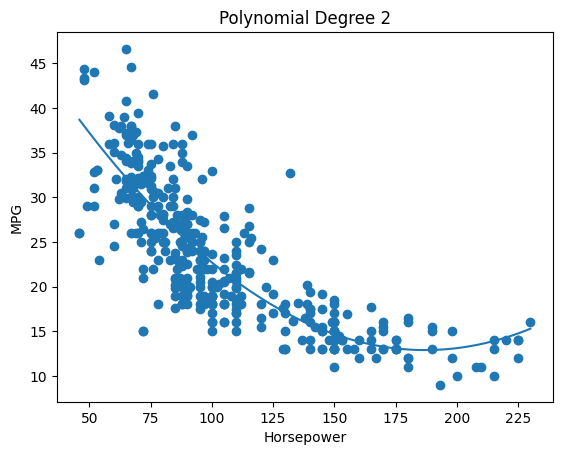


Polynomial Degree: 3
MSE: 18.460267222224626
RMSE: 4.296541309265469
R2: 0.6383217814053861


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


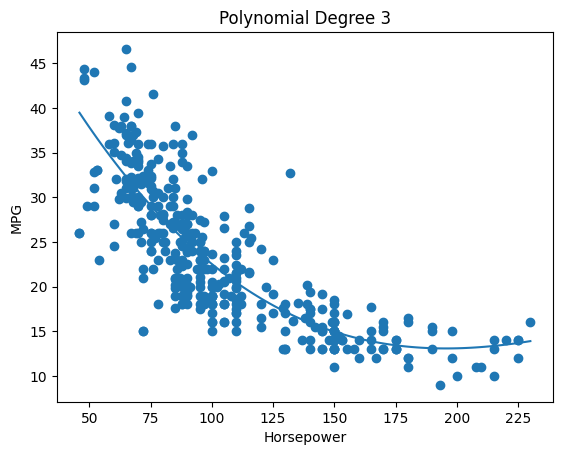


Polynomial Degree: 4
MSE: 18.268226874853184
RMSE: 4.274134634619409
R2: 0.6420842844016577


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


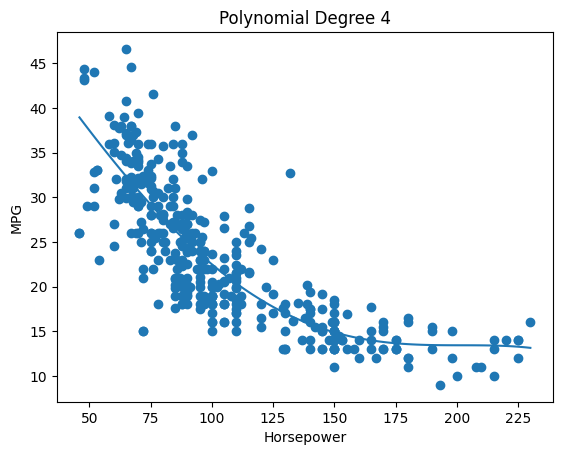


Ridge R2 (Degree 4): 0.6421473905292252


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.76945e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [2]:
# Scenario 2: Polynomial Regression

print("Name: Sharvesh S")
print("Roll No: 24BAD110")
print("Scenario 2: Polynomial Regression\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("auto-mpg.csv")

# Clean dataset
df = df.replace('?', np.nan)
df['horsepower'] = df['horsepower'].astype(float)
df = df.dropna()

# Select Feature & Target
X = df[['horsepower']]
y = df['mpg']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

degrees = [2, 3, 4]

for degree in degrees:

    print(f"\nPolynomial Degree: {degree}")

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_test_poly = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)

    # Plot curve
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    X_range_poly = scaler.transform(X_range_poly)
    y_range_pred = model.predict(X_range_poly)

    plt.figure()
    plt.scatter(X, y)
    plt.plot(X_range, y_range_pred)
    plt.title(f"Polynomial Degree {degree}")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.show()

# Ridge Regularization (Degree 4 example)
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

print("\nRidge R2 (Degree 4):",
      r2_score(y_test, ridge.predict(X_test_poly)))